# Tutorial 02 — Neural Networks and Backpropagation

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **What changes if the model learns its own non-linear representation?**

---

## 1. Why this matters

In tutorial 01 the interesting work was done by a human: we decided that the
model should see lag 24, that the hour should be encoded as a sine and a
cosine, that the temperature response might be non-linear. The model only
fitted coefficients to features we had already chosen.

A neural network moves that boundary. Given raw-ish inputs it constructs its
own intermediate quantities — its own *representation* — and fits the task on
top of them. That single change is the hinge of the whole course: once a model
can learn representations, you can start asking what it should learn them
*from*, which is the question foundation models answer.

The notebook also sets up a comparison that matters for the rest of the
course. On a small tabular problem with carefully engineered features, a
neural network is *competitive with* gradient boosting — not obviously better,
and considerably more work to get there. Whatever the exact numbers come out
at when you run it, the reason we adopt neural networks is not that they win
this benchmark.

## 2. Historical context

The perceptron (Rosenblatt, 1958) is a single neuron with a threshold. It
cannot represent XOR, which Minsky and Papert showed in 1969, and the field
largely moved on. The missing pieces were *depth* and an efficient way to
train it. Backpropagation supplied the second: known in various forms from
Linnainmaa (1970) and Werbos (1974), it became the standard tool after
Rumelhart, Hinton and Williams (1986). Depth then had to wait for data, GPUs
and better initialisation — roughly until 2006–2012.

So: the algorithm in this notebook is from the 1980s. What changed was
everything around it.

## 3. Learning objectives

By the end of this notebook you can:

- write the forward pass of a neuron and an MLP in NumPy;
- derive and implement backpropagation for a two-layer network, and *verify*
  your gradients against finite differences;
- explain what an activation function is for, and why a linear one is useless;
- translate the NumPy version into PyTorch (`autograd`, `nn.Module`, an
  optimiser) and confirm the two agree;
- explain epochs, mini-batches, learning rate and early stopping;
- state honestly when a neural network is and is not the right tool.

In [1]:
from __future__ import annotations

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from torch import nn

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, make_supervised, time_split
from ai_power_course.metrics import mae, point_metrics, skill_score
from ai_power_course.models.baselines import baseline_suite
from ai_power_course.models.training import (
    Standardizer,
    TrainConfig,
    count_parameters,
    make_loader,
    predict,
    train_model,
)
from ai_power_course.plotting import COLORS, plot_learning_curve, use_course_style
from ai_power_course.results import Leaderboard, leaderboard_table, record

warnings.filterwarnings("ignore", category=FutureWarning)
use_course_style()
set_seed()
torch.set_num_threads(4)
print(f"torch {torch.__version__} | reduced (CI) configuration: {fast_mode()}")

torch 2.14.0+cpu | reduced (CI) configuration: False


## 4. Theory

### One neuron

$$y = \sigma\!\left(\sum_i w_i x_i + b\right) = \sigma(\mathbf{w}^\top\mathbf{x} + b)$$

A weighted sum, then a non-linearity. Without $\sigma$, stacking layers is
pointless: a composition of linear maps is a linear map, so a 50-layer linear
network has exactly the representational power of linear regression. The
activation is not a detail, it is the entire reason depth buys anything.

### A two-layer network

$$\mathbf{h} = \sigma(W_1\mathbf{x} + \mathbf{b}_1), \qquad \hat y = W_2\mathbf{h} + b_2$$

with squared-error loss $L = \tfrac{1}{2}(\hat y - y)^2$.

### Backpropagation is the chain rule with shared work

Going backwards, writing $\delta$ for the gradient of the loss with respect to
a layer's pre-activation:

$$\delta_2 = \hat y - y, \qquad
  \frac{\partial L}{\partial W_2} = \delta_2 \mathbf{h}^\top, \qquad
  \delta_1 = (W_2^\top \delta_2) \odot \sigma'(W_1\mathbf{x}+\mathbf{b}_1), \qquad
  \frac{\partial L}{\partial W_1} = \delta_1 \mathbf{x}^\top$$

The only insight is that $\delta_1$ reuses $\delta_2$. Computing each
parameter's derivative independently would cost $O(P^2)$; sharing the
intermediate results makes it $O(P)$ — about the same cost as the forward
pass. That efficiency, not the calculus, is why the technique matters.

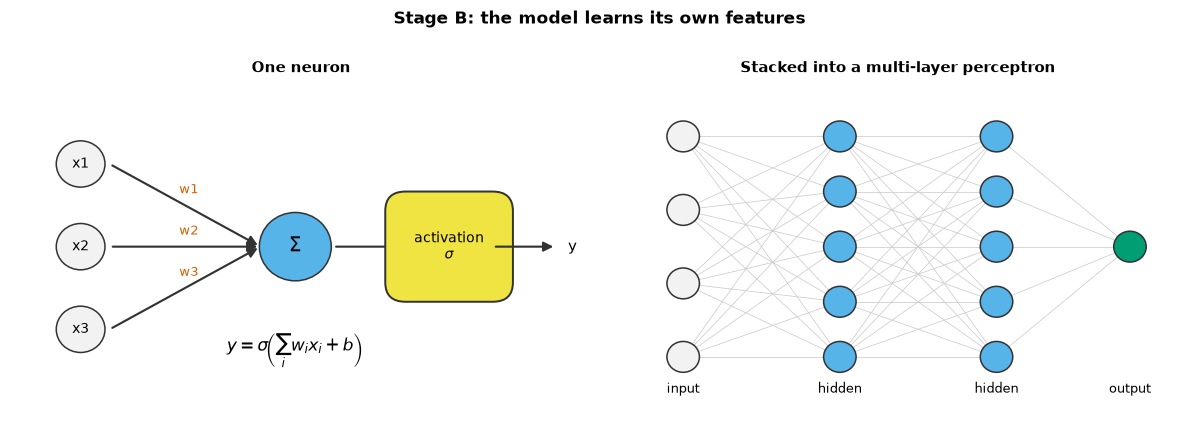

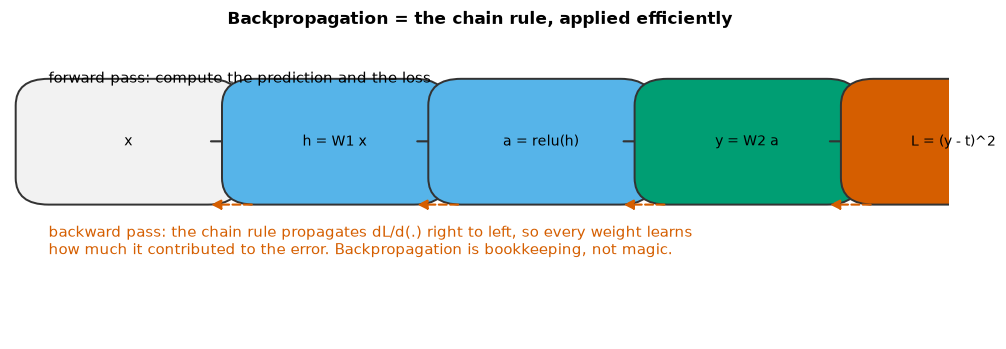

In [2]:
fig = diagrams.neuron_and_network()
plt.show()
fig = diagrams.backpropagation()
plt.show()

## 5. From scratch, in NumPy

### 5.1 Activation functions

Three that matter, and why ReLU took over.

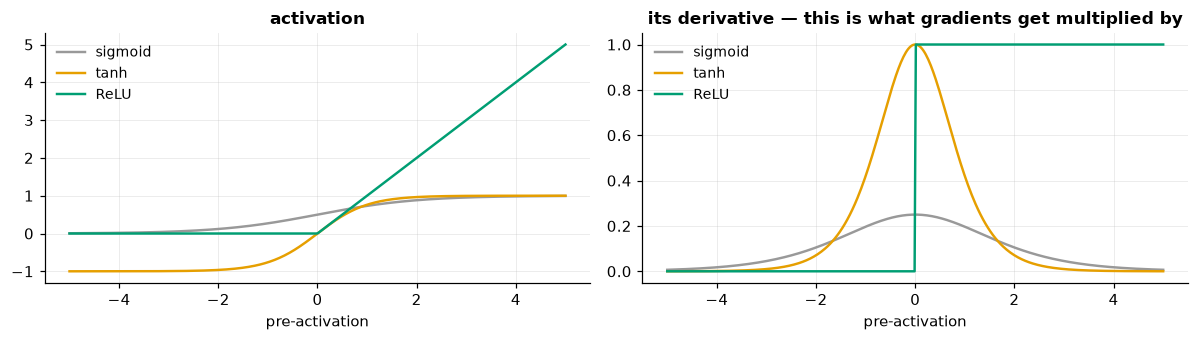

Look at the right panel. The sigmoid derivative peaks at 0.25 and is near zero
for |x| > 4. Multiply ten of those together during backpropagation and the
gradient is ~1e-6: that is the vanishing-gradient problem, and it is why deep
sigmoid networks were untrainable. ReLU's derivative is exactly 1 where active.


In [3]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, x)


def tanh(x: np.ndarray) -> np.ndarray:
    return np.tanh(x)


grid = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for name, fn, derivative in [
    ("sigmoid", sigmoid, lambda x: sigmoid(x) * (1 - sigmoid(x))),
    ("tanh", tanh, lambda x: 1 - np.tanh(x) ** 2),
    ("ReLU", relu, lambda x: (x > 0).astype(float)),
]:
    axes[0].plot(grid, fn(grid), label=name)
    axes[1].plot(grid, derivative(grid), label=name)
axes[0].set_title("activation")
axes[1].set_title("its derivative — this is what gradients get multiplied by")
for ax in axes:
    ax.legend()
    ax.set_xlabel("pre-activation")
fig.tight_layout()
plt.show()

print("Look at the right panel. The sigmoid derivative peaks at 0.25 and is near zero")
print("for |x| > 4. Multiply ten of those together during backpropagation and the")
print("gradient is ~1e-6: that is the vanishing-gradient problem, and it is why deep")
print("sigmoid networks were untrainable. ReLU's derivative is exactly 1 where active.")

### 5.2 A two-layer MLP with hand-written backpropagation

Small enough to read, complete enough to train.

In [4]:
class NumpyMLP:
    """A 2-layer MLP with explicit forward and backward passes.

    Everything PyTorch does automatically is written out here once, so that
    `loss.backward()` later is a convenience rather than a mystery.
    """

    def __init__(self, n_inputs: int, n_hidden: int, seed: int = 0) -> None:
        rng = np.random.default_rng(seed)
        # He initialisation: variance 2/n_in keeps activations from shrinking or
        # exploding as signals pass through ReLU layers.
        self.W1 = rng.normal(0, np.sqrt(2.0 / n_inputs), size=(n_inputs, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(0, np.sqrt(2.0 / n_hidden), size=(n_hidden, 1))
        self.b2 = np.zeros(1)

    def forward(self, X: np.ndarray) -> np.ndarray:
        self.X = X
        self.z1 = X @ self.W1 + self.b1          # pre-activation
        self.a1 = np.maximum(0.0, self.z1)       # ReLU
        self.z2 = self.a1 @ self.W2 + self.b2    # linear output
        return self.z2

    def backward(self, y_true: np.ndarray) -> dict[str, np.ndarray]:
        """Gradients of the mean squared error, averaged over the batch."""
        n = len(y_true)
        y_true = y_true.reshape(-1, 1)

        delta2 = (self.z2 - y_true) / n          # dL/dz2
        grad_W2 = self.a1.T @ delta2
        grad_b2 = delta2.sum(axis=0)

        delta1 = (delta2 @ self.W2.T) * (self.z1 > 0)   # chain rule through ReLU
        grad_W1 = self.X.T @ delta1
        grad_b1 = delta1.sum(axis=0)

        return {"W1": grad_W1, "b1": grad_b1, "W2": grad_W2, "b2": grad_b2}

    def step(self, gradients: dict[str, np.ndarray], learning_rate: float) -> None:
        for name, gradient in gradients.items():
            setattr(self, name, getattr(self, name) - learning_rate * gradient)

    @staticmethod
    def loss(prediction: np.ndarray, y_true: np.ndarray) -> float:
        return float(np.mean((prediction.reshape(-1) - y_true.reshape(-1)) ** 2) / 2)

### 5.3 Do not trust a gradient you have not checked

A sign error in `backward` still trains — badly, and silently. The only
reliable defence is to compare against a finite-difference approximation:

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta+\epsilon) - L(\theta-\epsilon)}{2\epsilon}$$

Every deep-learning framework's test suite does this. So should you, the first
time you write a custom layer.

In [5]:
set_seed()
rng = np.random.default_rng(0)
X_toy = rng.normal(size=(24, 5))
y_toy = rng.normal(size=24)

net = NumpyMLP(n_inputs=5, n_hidden=7, seed=1)
net.forward(X_toy)
analytic = net.backward(y_toy)

EPSILON = 1e-6
errors = {}
for name in ("W1", "b1", "W2", "b2"):
    parameter = getattr(net, name)
    numeric = np.zeros_like(parameter)
    for index in np.ndindex(parameter.shape):
        original = parameter[index]
        parameter[index] = original + EPSILON
        loss_plus = net.loss(net.forward(X_toy), y_toy)
        parameter[index] = original - EPSILON
        loss_minus = net.loss(net.forward(X_toy), y_toy)
        parameter[index] = original
        numeric[index] = (loss_plus - loss_minus) / (2 * EPSILON)
    relative = np.abs(analytic[name] - numeric).max() / (np.abs(numeric).max() + 1e-12)
    errors[name] = relative
    print(f"  {name:3s}  max relative error {relative:.2e}   {'OK' if relative < 1e-5 else 'WRONG'}")

assert max(errors.values()) < 1e-5, "backpropagation is incorrect"
print("\nThe hand-derived gradients match numerical differentiation. Now we can train.")

  W1   max relative error 2.56e-10   OK
  b1   max relative error 4.22e-10   OK
  W2   max relative error 1.16e-10   OK
  b2   max relative error 1.61e-10   OK

The hand-derived gradients match numerical differentiation. Now we can train.


### 5.4 Gradient descent on a problem we can see

Before the power system: fit the V-shaped temperature-to-load relationship
from tutorial 01, which no linear model can represent.

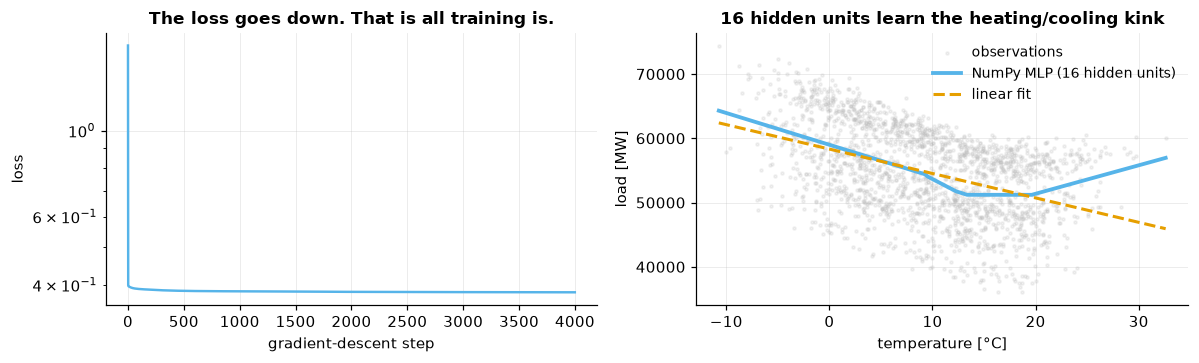

The network was never told that load depends on temperature non-linearly, nor
where the kink is. It found both. That is representation learning, in miniature.


In [6]:
set_seed()
frame = load_energy_data().frame
sample = frame.sample(2000, random_state=0).sort_values("temperature_c")
temp_raw = sample.temperature_c.to_numpy()
load_raw = sample.load_mw.to_numpy()

# Standardise both — gradient descent is badly conditioned on raw MW values.
temp = (temp_raw - temp_raw.mean()) / temp_raw.std()
load = (load_raw - load_raw.mean()) / load_raw.std()

toy_net = NumpyMLP(n_inputs=1, n_hidden=16, seed=3)
losses = []
for epoch in range(scaled(full=4000, fast=400)):
    prediction = toy_net.forward(temp.reshape(-1, 1))
    losses.append(toy_net.loss(prediction, load))
    toy_net.step(toy_net.backward(load), learning_rate=0.05)

linear_fit = np.polyfit(temp, load, deg=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].semilogy(losses, color=COLORS["mlp"])
axes[0].set_xlabel("gradient-descent step")
axes[0].set_ylabel("loss")
axes[0].set_title("The loss goes down. That is all training is.")

axes[1].scatter(temp_raw, load_raw, s=4, alpha=0.2, color="#bbbbbb", label="observations")
order = np.argsort(temp)
axes[1].plot(temp_raw[order], toy_net.forward(temp.reshape(-1, 1)).reshape(-1)[order]
             * load_raw.std() + load_raw.mean(),
             color=COLORS["mlp"], lw=2.5, label="NumPy MLP (16 hidden units)")
axes[1].plot(temp_raw[order], np.polyval(linear_fit, temp[order]) * load_raw.std()
             + load_raw.mean(), color=COLORS["linear"], lw=2, ls="--", label="linear fit")
axes[1].set_xlabel("temperature [°C]")
axes[1].set_ylabel("load [MW]")
axes[1].set_title("16 hidden units learn the heating/cooling kink")
axes[1].legend()
fig.tight_layout()
plt.show()

print("The network was never told that load depends on temperature non-linearly, nor")
print("where the kink is. It found both. That is representation learning, in miniature.")

## 6. The same thing in PyTorch

### 6.1 Tensors and autograd

A `torch.Tensor` is a NumPy array that remembers where it came from. Setting
`requires_grad=True` makes PyTorch record every operation into a graph;
`.backward()` then walks that graph backwards applying the chain rule —
precisely what we wrote by hand above.

In [7]:
x = torch.tensor([2.0], requires_grad=True)
w = torch.tensor([3.0], requires_grad=True)
y = (w * x) ** 2 + 5 * x

y.backward()
print(f"y = (w*x)^2 + 5x   at w=3, x=2   ->  y = {y.item():.1f}")
print(f"  dy/dw = 2*w*x^2      analytic {2 * 3 * 2**2:6.1f}   autograd {w.grad.item():6.1f}")
print(f"  dy/dx = 2*w^2*x + 5  analytic {2 * 3**2 * 2 + 5:6.1f}   autograd {x.grad.item():6.1f}")
print("\nNo magic — just the chain rule, applied to a recorded graph.")

y = (w*x)^2 + 5x   at w=3, x=2   ->  y = 46.0
  dy/dw = 2*w*x^2      analytic   24.0   autograd   24.0
  dy/dx = 2*w^2*x + 5  analytic   41.0   autograd   41.0

No magic — just the chain rule, applied to a recorded graph.


### 6.2 The same MLP as an `nn.Module`

Same architecture, same initialisation scheme, same optimiser. If the two
implementations agree, our understanding is correct.

In [8]:
class TorchMLP(nn.Module):
    """The PyTorch twin of :class:`NumpyMLP`."""

    def __init__(self, n_inputs: int, n_hidden: int) -> None:
        super().__init__()
        self.layer1 = nn.Linear(n_inputs, n_hidden)
        self.layer2 = nn.Linear(n_hidden, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer2(torch.relu(self.layer1(x)))


set_seed()
torch_net = TorchMLP(1, 16)
# Copy the NumPy network's starting weights so the comparison is exact.
reference_net = NumpyMLP(n_inputs=1, n_hidden=16, seed=3)
with torch.no_grad():
    torch_net.layer1.weight.copy_(torch.tensor(reference_net.W1.T, dtype=torch.float32))
    torch_net.layer1.bias.copy_(torch.tensor(reference_net.b1, dtype=torch.float32))
    torch_net.layer2.weight.copy_(torch.tensor(reference_net.W2.T, dtype=torch.float32))
    torch_net.layer2.bias.copy_(torch.tensor(reference_net.b2, dtype=torch.float32))

inputs = torch.tensor(temp.reshape(-1, 1), dtype=torch.float32)
targets = torch.tensor(load.reshape(-1, 1), dtype=torch.float32)
optimizer = torch.optim.SGD(torch_net.parameters(), lr=0.05)

for _ in range(scaled(full=4000, fast=400)):
    optimizer.zero_grad()
    loss = 0.5 * ((torch_net(inputs) - targets) ** 2).mean()
    loss.backward()
    optimizer.step()

numpy_prediction = toy_net.forward(temp.reshape(-1, 1)).reshape(-1)
torch_prediction = torch_net(inputs).detach().numpy().reshape(-1)
print(f"NumPy  final loss : {losses[-1]:.6f}")
print(f"PyTorch final loss: {loss.item():.6f}")
print(f"max |prediction difference| : {np.abs(numpy_prediction - torch_prediction).max():.2e}")
print("\nIdentical, to floating-point precision. From here on: PyTorch.")

NumPy  final loss : 0.382674
PyTorch final loss: 0.382674
max |prediction difference| : 2.62e-05

Identical, to floating-point precision. From here on: PyTorch.


## 7. Power-system application

Back to the course benchmark: **day-ahead load forecasting**, same data, same
split, same features as tutorial 01. Only the model class changes.

In [9]:
HORIZON = 24
EXOGENOUS = ("temperature_c",)

train_raw, valid_raw, test_raw = time_split(frame)
X_train, y_train = make_supervised(train_raw, horizon=HORIZON, exogenous=EXOGENOUS)
X_valid, y_valid = make_supervised(valid_raw, horizon=HORIZON, exogenous=EXOGENOUS)
X_test, y_test = make_supervised(test_raw, horizon=HORIZON, exogenous=EXOGENOUS)

# Standardise features AND target, fitted on training data only. Neural networks
# need this far more than trees do: a feature measured in tens of thousands of MW
# produces enormous gradients and the optimiser diverges or crawls.
feature_scaler = Standardizer().fit(X_train.to_numpy())
target_scaler = Standardizer().fit(y_train.to_numpy().reshape(-1, 1))

Xs_train = feature_scaler.transform(X_train.to_numpy())
Xs_valid = feature_scaler.transform(X_valid.to_numpy())
Xs_test = feature_scaler.transform(X_test.to_numpy())
ys_train = target_scaler.transform(y_train.to_numpy().reshape(-1, 1))
ys_valid = target_scaler.transform(y_valid.to_numpy().reshape(-1, 1))

print(f"features {Xs_train.shape} | target mean {target_scaler.mean_.ravel()[0]:,.0f} MW, "
      f"std {target_scaler.std_.ravel()[0]:,.0f} MW")

features (17328, 26) | target mean 54,906 MW, std 6,912 MW


In [10]:
set_seed()
model = nn.Sequential(
    nn.Linear(Xs_train.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
)
print(model)
print(f"\ntrainable parameters: {count_parameters(model):,}")

train_loader = make_loader(Xs_train, ys_train, batch_size=64, shuffle=True)
valid_loader = make_loader(Xs_valid, ys_valid, batch_size=256)

started = time.perf_counter()
history = train_model(
    model,
    train_loader,
    valid_loader,
    loss_fn=nn.MSELoss(),
    config=TrainConfig(
        epochs=scaled(full=60, fast=3),
        learning_rate=1e-3,
        patience=10,
        verbose=True,
        log_every=5,
    ),
)
mlp_seconds = time.perf_counter() - started
print(f"\nbest epoch {history.best_epoch}, {mlp_seconds:.1f} s on CPU")

Sequential(
  (0): Linear(in_features=26, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=1, bias=True)
)

trainable parameters: 11,777


epoch   5/60  train 0.08813  val 0.10714


epoch  10/60  train 0.07560  val 0.11698


epoch  15/60  train 0.06861  val 0.11582
early stop at epoch 15 (best epoch 5)

best epoch 5, 5.3 s on CPU


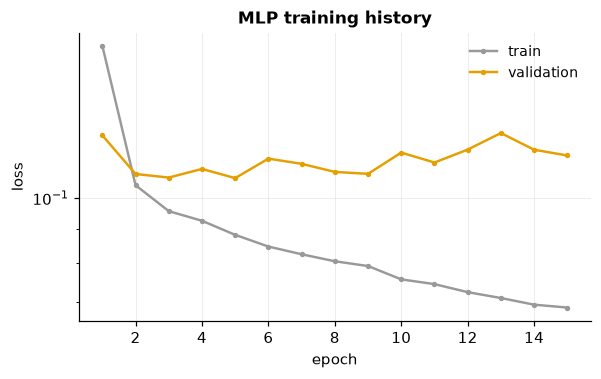

MLP test MAE: 1,624.0 MW


In [11]:
fig, ax = plt.subplots(figsize=(6, 3.4))
plot_learning_curve(history.as_dict(), title="MLP training history", ax=ax)
plt.show()

mlp_prediction = target_scaler.inverse_transform(predict(model, Xs_test)).reshape(-1)
print(f"MLP test MAE: {mae(y_test, mlp_prediction):,.1f} MW")

### 7.1 Epochs, batches and learning rate — the three knobs

- An **epoch** is one pass over the training set.
- A **mini-batch** is the subset used for one parameter update. Smaller
  batches mean noisier gradients and more updates per epoch; the noise itself
  has a mild regularising effect.
- The **learning rate** is the step size, and it is the hyper-parameter that
  most often decides whether training works at all.

Rather than assert that, measure it.

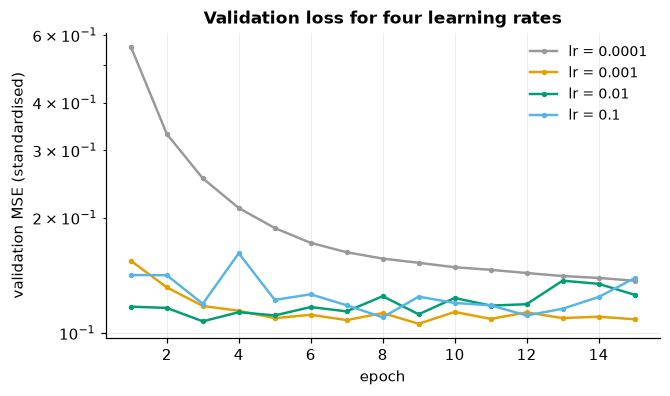

  lr = 0.0001  final validation loss 0.13690
  lr = 0.001   final validation loss 0.10860
  lr = 0.01    final validation loss 0.12583
  lr = 0.1     final validation loss 0.13907

Too small: still crawling when the budget runs out. Too large: the optimiser
steps past the minimum and the loss stalls high or oscillates. There is a band
of roughly one order of magnitude that works, and it must be found empirically.


In [12]:
set_seed()
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]
lr_curves = {}
for learning_rate in learning_rates:
    set_seed()
    probe = nn.Sequential(
        nn.Linear(Xs_train.shape[1], 64), nn.ReLU(), nn.Linear(64, 1)
    )
    probe_history = train_model(
        probe,
        make_loader(Xs_train, ys_train, batch_size=128, shuffle=True),
        make_loader(Xs_valid, ys_valid, batch_size=512),
        config=TrainConfig(
            epochs=scaled(full=15, fast=3), learning_rate=learning_rate,
            patience=None, verbose=False,
        ),
    )
    lr_curves[f"lr = {learning_rate:g}"] = probe_history.val_loss

fig, ax = plt.subplots(figsize=(6.5, 3.6))
plot_learning_curve(lr_curves, title="Validation loss for four learning rates",
                    ylabel="validation MSE (standardised)", ax=ax)
plt.show()

for label, curve in lr_curves.items():
    print(f"  {label:12s} final validation loss {curve[-1]:.5f}")
print("\nToo small: still crawling when the budget runs out. Too large: the optimiser")
print("steps past the minimum and the loss stalls high or oscillates. There is a band")
print("of roughly one order of magnitude that works, and it must be found empirically.")

## 8. Baseline comparison — the honest result

The whole point of this section. Same data, same split, same target.

,MAE,RMSE,R2,Bias,MAPE_%,Skill vs. baseline
MLP (PyTorch),1624.032,2190.210,0.896,72.396,3.047,0.258
Gradient boosting,1776.462,2400.515,0.875,574.800,3.345,0.187
Linear regression,2066.153,2651.899,0.847,359.230,3.892,0.102
seasonal naive (168 h),2218.972,2952.957,0.811,51.785,4.130,0.000


What each model stores:
  seasonal naive (168 h)     nothing — it copies a past value
  Linear regression          27 coefficients
  MLP (PyTorch)              11,777 weights
  Gradient boosting          400 trees, 24,400 nodes

Counting a decision-tree node and a network weight as the same unit of
'model size' would be meaningless. Compare accuracy, latency and memory instead.


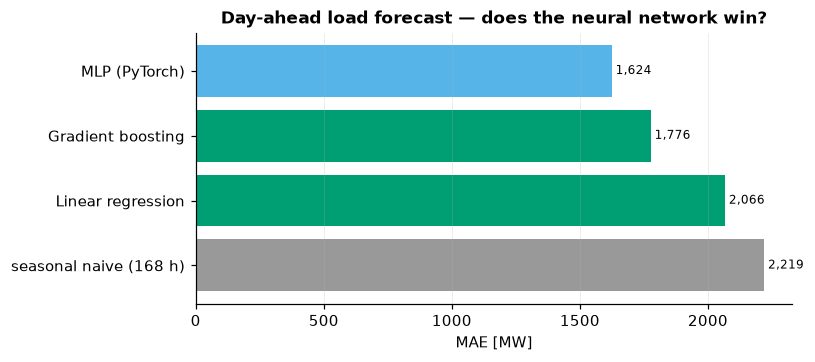

In [13]:
set_seed()
baselines = baseline_suite(
    frame.load_mw, y_test.index, horizon=HORIZON, train=train_raw.load_mw
)
reference_name = min(baselines, key=lambda name: mae(y_test, baselines[name]))
reference = baselines[reference_name]

linear = LinearRegression().fit(X_train, y_train)
boosting_started = time.perf_counter()
# early_stopping=False, matching tutorial 01's configuration exactly.
#
# The default is "auto", which switches early stopping ON above 10,000 samples
# -- and this training set is larger than that. sklearn then carves a RANDOM
# validation split out of what is a TIME SERIES, which is precisely the leak
# tutorial 01 spends a whole section warning about, and it also trains the
# model on 10% less data than the notebook says it does. It is why this
# contender used to score differently from tutorial 01's otherwise identical
# one.
boosting = HistGradientBoostingRegressor(
    max_iter=scaled(full=400, fast=60), learning_rate=0.06,
    early_stopping=False, random_state=0,
).fit(X_train, y_train)
boosting_seconds = time.perf_counter() - boosting_started

contenders = {
    reference_name: reference.to_numpy(),
    "Linear regression": linear.predict(X_test),
    "Gradient boosting": boosting.predict(X_test),
    "MLP (PyTorch)": mlp_prediction,
}

comparison = pd.DataFrame(
    {
        name: {
            **point_metrics(y_test, values),
            "Skill vs. baseline": skill_score(y_test, values, reference),
        }
        for name, values in contenders.items()
    }
).T.sort_values("MAE")
display(comparison.round(3))

# "Number of parameters" is not comparable across model families, so report what
# each one actually stores rather than forcing them into one column.
print("What each model stores:")
print(f"  {reference_name:26s} nothing — it copies a past value")
print(f"  {'Linear regression':26s} {X_train.shape[1] + 1:,} coefficients")
print(f"  {'MLP (PyTorch)':26s} {count_parameters(model):,} weights")
tree_nodes = sum(len(tree.nodes) for stage in boosting._predictors for tree in stage)
print(f"  {'Gradient boosting':26s} {boosting.n_iter_:,} trees, {tree_nodes:,} nodes")
print("\nCounting a decision-tree node and a network weight as the same unit of\n"
      "'model size' would be meaningless. Compare accuracy, latency and memory instead.")

fig, ax = plt.subplots(figsize=(7, 3.2))
ordered = comparison.MAE.sort_values(ascending=False)
ax.barh(ordered.index, ordered.to_numpy(),
        color=[COLORS["baseline"] if name == reference_name else COLORS["mlp"]
               if "MLP" in name else COLORS["tree"] for name in ordered.index])
ax.set_xlabel("MAE [MW]")
ax.set_title("Day-ahead load forecast — does the neural network win?")
ax.grid(axis="y", visible=False)
for y_pos, value in enumerate(ordered.to_numpy()):
    ax.text(value, y_pos, f" {value:,.0f}", va="center", fontsize=8)
plt.show()

In [14]:
best = comparison.index[0]
gap = comparison.loc["MLP (PyTorch)", "MAE"] / comparison.loc["Gradient boosting", "MAE"] - 1
print(f"Winner: {best}")
print(f"MLP is {gap:+.1%} on MAE relative to gradient boosting.")
print(f"\nTraining time: gradient boosting {boosting_seconds:.1f} s, MLP {mlp_seconds:.1f} s "
      f"({mlp_seconds / max(boosting_seconds, 1e-9):.1f}x).")

Winner: MLP (PyTorch)
MLP is -8.6% on MAE relative to gradient boosting.

Training time: gradient boosting 1.1 s, MLP 5.3 s (4.6x).


**Read that gap against its cost.** The MLP and the tree ensembles land within
a few percent of each other — a difference comparable to what you get by
changing a tree's `max_depth`, or by re-running with a different seed. Getting
there required standardising the inputs, choosing a learning rate, choosing an
architecture, and several times the training time. Gradient boosting required
none of that and has no random-seed sensitivity worth mentioning.

So the honest summary is: **on small tabular data with good features, neural
networks are competitive, not transformative.** Anyone reporting a
single-digit-percent improvement here should cross-validate it before
believing it — tutorial 01 measured a fold-to-fold spread of about 9% on this
very problem, which is larger than the gap between these models.

That is not an argument against neural networks. It is an argument about
*where their advantage actually lies*:

| | trees | neural networks |
|---|---|---|
| small tabular data, engineered features | **excellent** | fine |
| raw sequences, images, text, graphs | poor | **the only option** |
| transfer to a new but related task | none | **possible** |
| pretraining on unlabelled data | not really | **the whole point** |

Everything in the right-hand column is what the rest of this course is about.
We did not switch to neural networks to win this benchmark; we switched
because trees cannot be pretrained, cannot consume a raw sequence, and cannot
hand a learned representation to the next task. A gradient-boosting model is a
set of if-then rules over *your* features: there is no hidden layer to reuse,
nothing to transfer, and no way to train it on data that has no labels.

## 9. Inspect the model

What has the first layer learned to look at?

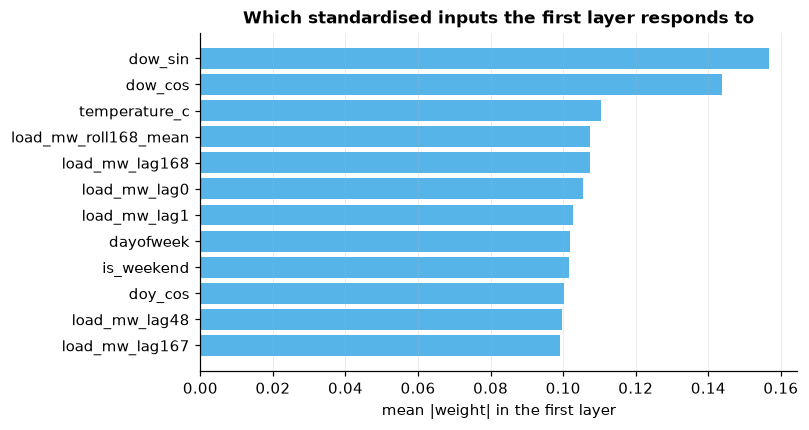

Comparable with the tree feature importances from tutorial 01 — the recent lags
and the daily/weekly ones dominate. Two very different model families agreeing
about which information matters is mild evidence that the signal is real.

Do not over-read it: first-layer weight magnitude is a crude proxy, not an
explanation. Tutorial 05 makes the same warning about attention weights.


In [15]:
first_layer = model[0].weight.detach().numpy()
attention_like = pd.Series(np.abs(first_layer).mean(axis=0), index=X_train.columns)
attention_like = attention_like.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
top = attention_like.head(12)[::-1]
ax.barh(top.index, top.to_numpy(), color=COLORS["mlp"])
ax.set_xlabel("mean |weight| in the first layer")
ax.set_title("Which standardised inputs the first layer responds to")
ax.grid(axis="y", visible=False)
plt.show()

print("Comparable with the tree feature importances from tutorial 01 — the recent lags\n"
      "and the daily/weekly ones dominate. Two very different model families agreeing\n"
      "about which information matters is mild evidence that the signal is real.\n\n"
      "Do not over-read it: first-layer weight magnitude is a crude proxy, not an\n"
      "explanation. Tutorial 05 makes the same warning about attention weights.")

## 10. Failure analysis

### Failure 1 — no activation function

The claim from section 4, tested: without non-linearity, depth is worthless.

In [16]:
set_seed()
linear_stack = nn.Sequential(
    nn.Linear(Xs_train.shape[1], 128), nn.Linear(128, 64), nn.Linear(64, 1)
)
train_model(
    linear_stack,
    make_loader(Xs_train, ys_train, batch_size=128, shuffle=True),
    make_loader(Xs_valid, ys_valid, batch_size=512),
    config=TrainConfig(epochs=scaled(full=25, fast=3), learning_rate=1e-3, verbose=False),
)
stack_prediction = target_scaler.inverse_transform(predict(linear_stack, Xs_test)).reshape(-1)

print(f"3-layer network WITHOUT activations : MAE {mae(y_test, stack_prediction):,.1f} MW"
      f"  ({count_parameters(linear_stack):,} parameters)")
print(f"plain linear regression             : MAE {mae(y_test, linear.predict(X_test)):,.1f} MW"
      f"  ({X_train.shape[1] + 1:,} parameters)")
print(f"\n{count_parameters(linear_stack):,} parameters bought essentially nothing over "
      f"{X_train.shape[1] + 1} coefficients,")
print("because the composition of three linear maps is a linear map. Any small residual")
print("difference is optimisation noise, not extra capacity. The activation function is")
print("the whole of 'deep' in deep learning.")

3-layer network WITHOUT activations : MAE 2,056.3 MW  (11,777 parameters)
plain linear regression             : MAE 2,066.2 MW  (27 parameters)

11,777 parameters bought essentially nothing over 27 coefficients,
because the composition of three linear maps is a linear map. Any small residual
difference is optimisation noise, not extra capacity. The activation function is
the whole of 'deep' in deep learning.


### Failure 2 — an over-sized network with no regularisation

Watch the validation curve turn upwards while the training curve keeps falling.

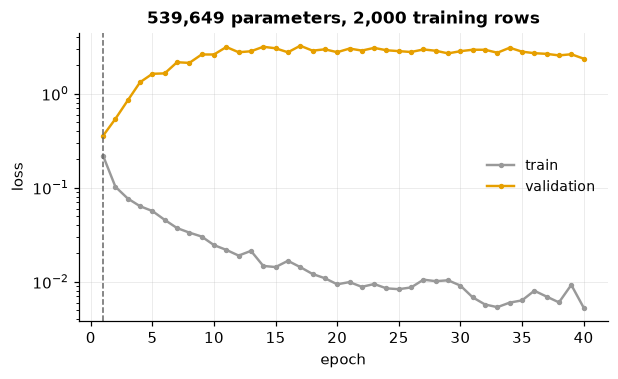

539,649 parameters for 2,000 training examples.
Best validation epoch: 1 of 40.
Everything after that point is memorisation. `train_model` restores the best
weights, which is what early stopping means in practice.


In [17]:
set_seed()
oversized = nn.Sequential(
    nn.Linear(Xs_train.shape[1], 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 1),
)
overfit_history = train_model(
    oversized,
    make_loader(Xs_train[:2000], ys_train[:2000], batch_size=32, shuffle=True),
    make_loader(Xs_valid, ys_valid, batch_size=512),
    config=TrainConfig(
        epochs=scaled(full=40, fast=4), learning_rate=1e-3, patience=None, verbose=False
    ),
)

fig, ax = plt.subplots(figsize=(6.2, 3.4))
plot_learning_curve(overfit_history.as_dict(),
                    title=f"{count_parameters(oversized):,} parameters, 2,000 training rows",
                    ax=ax)
ax.axvline(overfit_history.best_epoch, ls="--", color="#666", lw=1)
plt.show()

print(f"{count_parameters(oversized):,} parameters for 2,000 training examples.")
print(f"Best validation epoch: {overfit_history.best_epoch} of {len(overfit_history.val_loss)}.")
print("Everything after that point is memorisation. `train_model` restores the best")
print("weights, which is what early stopping means in practice.")

## 11. Record the result

In [18]:
Leaderboard().clear(tutorial=2)
record(
    model="MLP (2 hidden layers)",
    tutorial=2,
    metrics={
        **point_metrics(y_test, mlp_prediction),
        "Skill": skill_score(y_test, mlp_prediction, reference),
    },
    n_parameters=count_parameters(model),
    train_seconds=mlp_seconds,
    notes="same engineered features as tutorial 01",
)
display(leaderboard_table())

Bias       MAE  \
Tutorial Model                                                           
6        Transformer (encoder, 2 layers)             269.344  1602.925   
2        MLP (2 hidden layers)                        72.396  1624.032   
1        Random forest                               228.205  1636.504   
3        LSTM                                        475.708  1639.269   
         Vanilla RNN                                 568.151  1686.095   
1        Gradient boosting                           574.800  1776.462   
         Linear regression                           359.230  2066.153   
         seasonal naive (168 h)                       51.785  2218.972   
         climatology (hour x weekday)                973.565  3092.499   
         persistence (h=24) = seasonal naive (24 h)   30.224  3358.186   

                                                     MAPE_%     R2      RMSE  \
Tutorial Model                                                                 
6        Transformer (encoder, 2 layers)              3.009  0.895  2200.132   
2        MLP (2 hidden layers)                        3.047  0.896  2190.210   
1        Random forest                                3.067  0.889  2260.824   
3        LSTM                                         3.083  0.890  2260.473   
         Vanilla RNN                                  3.189  0.886  2296.802   
1        Gradient boosting                            3.345  0.875  2400.515   
         Linear regression                            3.892  0.847  2651.899   
         seasonal naive (168 h)                       4.130  0.811  2952.957   
         climatology (hour x weekday)                 5.864  0.715  3623.821   
         persistence (h=24) = seasonal naive (24 h)   6.372  0.541  4600.202   

                                                     Skill  \
Tutorial Model                                               
6        Transformer (encoder, 2 layers)             0.271   
2        MLP (2 hidden layers)                       0.258   
1        Random forest                               0.234   
3        LSTM                                        0.251   
         Vanilla RNN                                 0.239   
1        Gradient boosting                           0.187   
         Linear regression                           0.102   
         seasonal naive (168 h)                      0.000   
         climatology (hour x weekday)               -0.227   
         persistence (h=24) = seasonal naive (24 h) -0.558   

                                                                                               Notes  \
Tutorial Model                                                                                         
6        Transformer (encoder, 2 layers)             raw 168 h window, 6 channels, stride-4 training   
2        MLP (2 hidden layers)                               same engineered features as tutorial 01   
1        Random forest                                            engineered lag + calendar features   
3        LSTM                                                           raw 168 h window, 6 channels   
         Vanilla RNN                                                    raw 168 h window, 6 channels   
1        Gradient boosting                                        engineered lag + calendar features   
         Linear regression                                        engineered lag + calendar features   
         seasonal naive (168 h)                                                     trivial baseline   
         climatology (hour x weekday)                                               trivial baseline   
         persistence (h=24) = seasonal naive (24 h)                                 trivial baseline   

                                                       Params  Train_s  \
Tutorial Model                                                           
6        Transformer (encoder, 2 layers)             102104.0   

## 12. Exercises

**1 — Conceptual.** The MLP and gradient boosting see *identical* inputs and
produce similar accuracy, yet only one of them can be pretrained on unlabelled
data and reused elsewhere. Explain precisely why. Your answer should mention
what a trained tree ensemble actually stores, and what an MLP's hidden layer
stores. Then name one power-system situation where that difference decides the
architecture.

**2 — Coding.** Extend `NumpyMLP` to two hidden layers and verify the new
gradients with the finite-difference check in section 5.3. (Do the check
*before* you train anything — a wrong gradient still produces a decreasing
loss curve, which is why this exercise exists.) Then reproduce the same
architecture in PyTorch and confirm the two agree to 1e-5.

**3 — Research.** Our MLP consumes the same hand-engineered lag features as
the trees. Remove them: feed the network the raw last 168 hourly load values
and nothing else — no calendar encodings, no rolling statistics. Does it
recover the lost information? How many training epochs does it need to match
the feature-engineered version, and does it ever? This experiment is the
bridge to tutorial 03, where the *architecture* rather than the feature list
encodes the temporal structure.

## 13. Key takeaways

- **A neuron is a weighted sum plus a non-linearity**, and without the
  non-linearity a deep network collapses to linear regression. Measured above:
  roughly twelve thousand parameters performing no better than twenty-seven.
- **Backpropagation is the chain rule with shared intermediate results.** It
  is cheap, it is mechanical, and you should check your implementation of it
  against finite differences the first time you write one.
- **The optimiser needs standardised inputs and a learning rate in the right
  order of magnitude.** Trees need neither. That is a real cost.
- **The neural network was competitive with the tree ensembles, not clearly
  better** — and the gap between them is smaller than the fold-to-fold spread
  measured in tutorial 01. On small tabular problems with good features,
  expect a tie and budget for the extra tuning effort accordingly.
- **We adopt neural networks for what comes next**: raw sequences, learned
  representations, pretraining and transfer — none of which a tree ensemble
  can do.

## 14. Further reading

- Rumelhart, Hinton & Williams, "Learning representations by back-propagating
  errors", *Nature* 323, 1986.
- Goodfellow, Bengio & Courville, *Deep Learning*, ch. 6 (feed-forward
  networks) and ch. 8 (optimisation). <https://www.deeplearningbook.org/>
- Karpathy, "A recipe for training neural networks" (2019) — the practical
  debugging checklist this notebook's failure section is modelled on.
  <https://karpathy.github.io/2019/04/25/recipe/>
- Grinsztajn, Oyallon & Varoquaux, "Why do tree-based models still outperform
  deep learning on typical tabular data?", NeurIPS 2022.
  [arXiv:2207.08815](https://arxiv.org/abs/2207.08815)
- PyTorch autograd tutorial:
  <https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html>

---

**Next:** [Tutorial 03 — Learning from Sequences: RNNs and LSTMs](03_rnns_and_lstms.ipynb).
We stop handing the model a list of lags and give it the sequence itself.